In [1]:
import numpy as np

# ==========================================
# 1. CORE MATHEMATICS ENGINE
# ==========================================
class NuralMaths:
    """Provides low-level mathematical operations and weight initializations."""
    
    @staticmethod
    def neuralNet(map_weights, map_biases):
        """Initializes weight and bias matrices with scaled random values for network stability."""
        weights = np.random.randn(*map_weights) * 0.01
        biases = np.random.randn(*map_biases) * 0.01
        return weights, biases

    @staticmethod
    def CNeuron(input_matrix, weight_matrix, bias):
        """Computes the dot product sum and adds the bias for spatial feature extraction."""
        dot_product_sum = np.sum(input_matrix * weight_matrix)
        return dot_product_sum + np.sum(bias)


# ==========================================
# 2. BASE MODULE ARCHITECTURE
# ==========================================
class Module:
    """The base class inherited by all neural network layers. Manages training states and forward routing."""
    
    def __init__(self):
        self.training = True  # Indicates whether the network is in training or evaluation mode.

    def __call__(self, x):
        """Allows instances to be called as functions, routing inputs to the forward method."""
        return self.forward(x)

    def forward(self, x):
        """Placeholder for the forward pass, to be overridden by subclasses."""
        raise NotImplementedError

    def backward(self, d_out):
        """Placeholder for the backward pass, to be overridden by subclasses."""
        raise NotImplementedError

    def train(self):
        """Sets the module and all internal behaviors to training mode."""
        self.training = True

    def eval(self):
        """Sets the module to evaluation mode, disabling layers like Dropout."""
        self.training = False


# ==========================================
# 3. NETWORK LAYERS
# ==========================================
class Linear(Module):
    """A fully connected (dense) layer that applies a linear transformation to the incoming data."""
    
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weights, self.biases = NuralMaths.neuralNet((out_features, in_features), (out_features, 1))
        
        # Memory allocation for gradients and inputs
        self.d_weights = np.zeros_like(self.weights)
        self.d_biases = np.zeros_like(self.biases)
        self.inputs = None 

    def forward(self, x):
        """Performs matrix multiplication on the input and adds the bias."""
        self.inputs = x 
        return np.dot(self.weights, x) + self.biases.flatten()

    def backward(self, d_out):
        """Computes the gradients for weights and biases, and propagates the error backward."""
        # Reshape inputs to ensure correct matrix multiplication dimensions
        inputs_reshaped = self.inputs.reshape(1, -1)
        d_out_reshaped = d_out.reshape(-1, 1)

        self.d_weights = np.dot(d_out_reshaped, inputs_reshaped)
        self.d_biases = np.sum(d_out_reshaped, axis=1, keepdims=True)
        
        d_inputs = np.dot(self.weights.T, d_out)
        return d_inputs

# Fully Connected / Linear Layer

Let's create a tiny neural network layer with **3 input features** and **2 output features**.

### **1. The Setup (Defining our Variables)**

Let's assume our network has initialized some small, random numbers for the weights and biases, and we are passing in a single data point.

* **Input ($\mathbf{x}$):** A vector with 3 features.

$$\mathbf{x} = \begin{bmatrix} 1 \\ 2 \\ -1 \end{bmatrix}$$


* **Weights ($W$):** A matrix of shape (2 outputs, 3 inputs).

$$W = \begin{bmatrix} 0.1 & 0.2 & 0.3 \\ -0.1 & 0.0 & 0.1 \end{bmatrix}$$


* **Biases ($\mathbf{b}$):** A vector with 2 outputs.

$$\mathbf{b} = \begin{bmatrix} 0.5 \\ -0.2 \end{bmatrix}$$

---

### **2. The Forward Pass**

*Formula: $\mathbf{y} = W \mathbf{x} + \mathbf{b}$*

First, we perform the matrix multiplication (dot product) of the Weights and the Input ($W \mathbf{x}$):


$$W \mathbf{x} = \begin{bmatrix} 0.1 & 0.2 & 0.3 \\ -0.1 & 0.0 & 0.1 \end{bmatrix} \begin{bmatrix} 1 \\ 2 \\ -1 \end{bmatrix}$$

$$W \mathbf{x} = \begin{bmatrix} (0.1 \times 1) + (0.2 \times 2) + (0.3 \times -1) \\ (-0.1 \times 1) + (0.0 \times 2) + (0.1 \times -1) \end{bmatrix} = \begin{bmatrix} 0.1 + 0.4 - 0.3 \\ -0.1 + 0 - 0.1 \end{bmatrix} = \begin{bmatrix} 0.2 \\ -0.2 \end{bmatrix}$$

Next, we add the Biases ($\mathbf{b}$):


$$\mathbf{y} = \begin{bmatrix} 0.2 \\ -0.2 \end{bmatrix} + \begin{bmatrix} 0.5 \\ -0.2 \end{bmatrix} = \begin{bmatrix} 0.7 \\ -0.4 \end{bmatrix}$$

**Result:** The forward pass outputs $\begin{bmatrix} 0.7 \\ -0.4 \end{bmatrix}$. This is what gets passed to the next layer (or the loss function).

---

### **3. The Backward Pass**

Let's imagine the rest of the network did its job, calculated the final loss, and sent the error gradient *backward* to our layer. We'll call this incoming gradient **`d_out`** ($\frac{\partial L}{\partial \mathbf{y}}$).

Let's assume the incoming error gradient is:


$$\frac{\partial L}{\partial \mathbf{y}} = \begin{bmatrix} 1.0 \\ -1.0 \end{bmatrix}$$

Now we need to calculate three things using the formulas from earlier:

#### **A. Gradient of the Weights (`self.d_weights`)**

*Formula: $\frac{\partial L}{\partial W} = \frac{\partial L}{\partial \mathbf{y}} \mathbf{x}^T$*

We multiply the incoming gradient by the transpose of our original input ($\mathbf{x}^T$). This gives us a matrix of the exact same shape as our original Weights, telling us how to adjust each specific weight.

$$\frac{\partial L}{\partial W} = \begin{bmatrix} 1.0 \\ -1.0 \end{bmatrix} \begin{bmatrix} 1 & 2 & -1 \end{bmatrix}$$

$$\frac{\partial L}{\partial W} = \begin{bmatrix} (1.0 \times 1) & (1.0 \times 2) & (1.0 \times -1) \\ (-1.0 \times 1) & (-1.0 \times 2) & (-1.0 \times -1) \end{bmatrix} = \begin{bmatrix} 1.0 & 2.0 & -1.0 \\ -1.0 & -2.0 & 1.0 \end{bmatrix}$$

#### **B. Gradient of the Biases (`self.d_biases`)**

*Formula: $\frac{\partial L}{\partial \mathbf{b}} = \sum \frac{\partial L}{\partial \mathbf{y}}$*

Because we only processed one sample (not a batch of multiple samples), the gradient for the biases is simply exactly equal to the incoming error gradient.

$$\frac{\partial L}{\partial \mathbf{b}} = \begin{bmatrix} 1.0 \\ -1.0 \end{bmatrix}$$

#### **C. Gradient of the Inputs (`d_inputs`)**

*Formula: $\frac{\partial L}{\partial \mathbf{x}} = W^T \frac{\partial L}{\partial \mathbf{y}}$*

Finally, we calculate the error to pass further backward to the previous layer. We use the transpose of our Weights matrix ($W^T$).

$$W^T = \begin{bmatrix} 0.1 & -0.1 \\ 0.2 & 0.0 \\ 0.3 & 0.1 \end{bmatrix}$$

$$\frac{\partial L}{\partial \mathbf{x}} = \begin{bmatrix} 0.1 & -0.1 \\ 0.2 & 0.0 \\ 0.3 & 0.1 \end{bmatrix} \begin{bmatrix} 1.0 \\ -1.0 \end{bmatrix}$$

$$\frac{\partial L}{\partial \mathbf{x}} = \begin{bmatrix} (0.1 \times 1.0) + (-0.1 \times -1.0) \\ (0.2 \times 1.0) + (0.0 \times -1.0) \\ (0.3 \times 1.0) + (0.1 \times -1.0) \end{bmatrix} = \begin{bmatrix} 0.1 + 0.1 \\ 0.2 + 0 \\ 0.3 - 0.1 \end{bmatrix} = \begin{bmatrix} 0.2 \\ 0.2 \\ 0.2 \end{bmatrix}$$

**Result:** The `backward` function saves the weight and bias gradients so the optimizer can update them later, and it `returns` the vector $\begin{bmatrix} 0.2 \\ 0.2 \\ 0.2 \end{bmatrix}$ for the previous layer to use.

In [2]:
class Conv2d(Module):
    """A 2D convolutional layer that extracts spatial features using a sliding window."""
    
    def __init__(self, in_channels, out_channels, kernel_size, padding=0, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.padding = padding
        self.stride = stride
        self.out_channels = out_channels
        
        self.weights, self.biases = NuralMaths.neuralNet(
            (out_channels, in_channels, kernel_size, kernel_size), 
            (out_channels, 1)
        )
        
        self.d_weights = np.zeros_like(self.weights)
        self.d_biases = np.zeros_like(self.biases)
        self.inputs = None
        self.padded_input = None

    def forward(self, inputs):
        """Slides the convolutional filters across the input grid to generate feature maps."""
        self.inputs = inputs
        C, H, W = inputs.shape
        
        out_h = int((H + 2 * self.padding - self.kernel_size) / self.stride) + 1
        out_w = int((W + 2 * self.padding - self.kernel_size) / self.stride) + 1
        output = np.zeros((self.out_channels, out_h, out_w))
        
        if self.padding > 0:
            self.padded_input = np.pad(inputs, 
                                  ((0, 0), (self.padding, self.padding), (self.padding, self.padding)), 
                                  mode='constant', constant_values=0)
        else:
            self.padded_input = inputs

        for f in range(self.out_channels):
            for i in range(out_h):
                for j in range(out_w):
                    h_start, h_end = i * self.stride, i * self.stride + self.kernel_size
                    w_start, w_end = j * self.stride, j * self.stride + self.kernel_size
                    
                    image_chunk = self.padded_input[:, h_start:h_end, w_start:w_end]
                    output[f, i, j] = NuralMaths.CNeuron(image_chunk, self.weights[f], self.biases[f])
                    
        return output

    def backward(self, d_out):
        """Applies the spatial chain rule to compute weight gradients and input errors."""
        self.d_weights.fill(0)
        self.d_biases.fill(0)
        d_padded_input = np.zeros_like(self.padded_input)
        
        out_h, out_w = d_out.shape[1], d_out.shape[2]

        for f in range(self.out_channels):
            self.d_biases[f] = np.sum(d_out[f])
            
            for i in range(out_h):
                for j in range(out_w):
                    h_start, h_end = i * self.stride, i * self.stride + self.kernel_size
                    w_start, w_end = j * self.stride, j * self.stride + self.kernel_size
                    
                    image_patch = self.padded_input[:, h_start:h_end, w_start:w_end]
                    
                    self.d_weights[f] += image_patch * d_out[f, i, j]
                    d_padded_input[:, h_start:h_end, w_start:w_end] += self.weights[f] * d_out[f, i, j]

        # Removes the padding from the error grid before returning
        if self.padding > 0:
            p = self.padding
            d_inputs = d_padded_input[:, p:-p, p:-p]
        else:
            d_inputs = d_padded_input

        return d_inputs

# Convolutional / Conv2d Layer

Convolutional math is a bit more intricate than the `Linear` layer because it involves multidimensional tensors and sliding windows, but the core principles of the forward pass and the chain rule remain the same.

Let's first establish the notation to map the math to your code:

### **Notation & Variables**

* **$X$**: The original input tensor (`self.inputs`) of shape $(C, H, W)$ where $C$ is `in_channels`, $H$ is height, and $W$ is width.
* **$X'$**: The padded input tensor (`self.padded_input`).
* **$W$**: The filter/weight tensor (`self.weights`) of shape $(F, C, K, K)$ where $F$ is `out_channels` and $K$ is `kernel_size`.
* **$b$**: The bias vector (`self.biases`) of length $F$.
* **$Y$**: The output feature map (`output`) of shape $(F, H_{out}, W_{out})$.
* **$p, s$**: Padding (`self.padding`) and Stride (`self.stride`).
* **$L$**: The final scalar loss.
* **$\frac{\partial L}{\partial Y}$**: The incoming error gradient (`d_out`).

---

### **1. Output Dimensions**

Before the forward pass, your code calculates the spatial dimensions of the output feature map.

**Code equivalent:** `out_h = int((H + 2 * self.padding - self.kernel_size) / self.stride) + 1`

**Mathematical Formula:**


$$H_{out} = \left\lfloor \frac{H + 2p - K}{s} \right\rfloor + 1$$

$$W_{out} = \left\lfloor \frac{W + 2p - K}{s} \right\rfloor + 1$$

---

### **2. Forward Pass**

The `forward` method slides each filter across the padded input grid, performing an element-wise multiplication and sum (a dot product in 3D), and adds the bias.

**Code equivalent:** `output[f, i, j] = NuralMaths.CNeuron(image_chunk, self.weights[f], self.biases[f])`

**Mathematical Formula:**
For a specific output pixel at channel $f$, height $i$, and width $j$:


$$Y_{f, i, j} = b_f + \sum_{c=0}^{C-1} \sum_{m=0}^{K-1} \sum_{n=0}^{K-1} X'_{c, \, i \cdot s + m, \, j \cdot s + n} \cdot W_{f, c, m, n}$$


*(Note: $X'_{c, \, i \cdot s + m, \, j \cdot s + n}$ represents your `image_chunk`. The $i \cdot s$ and $j \cdot s$ handle the sliding window with your stride $s$.)*

---

### **3. Backward Pass (Backpropagation)**

The `backward` method distributes the incoming error (`d_out`) back to the biases, weights, and the input image.

#### **A. Gradient with respect to Biases (`self.d_biases`)**

The bias for filter $f$ contributes to every single pixel in the $f$-th output channel. Therefore, the gradient is the sum of the incoming errors for that entire feature map.
**Code equivalent:** `self.d_biases[f] = np.sum(d_out[f])`

**Mathematical Formula:**


$$\frac{\partial L}{\partial b_f} = \sum_{i=0}^{H_{out}-1} \sum_{j=0}^{W_{out}-1} \frac{\partial L}{\partial Y_{f, i, j}}$$

#### **B. Gradient with respect to Weights (`self.d_weights`)**

To find out how a specific weight affects the loss, we multiply the incoming error by the `image_patch` that the weight was applied to during the forward pass, summing across all positions where the filter was applied.
**Code equivalent:** `self.d_weights[f] += image_patch * d_out[f, i, j]`

**Mathematical Formula:**


$$\frac{\partial L}{\partial W_{f, c, m, n}} = \sum_{i=0}^{H_{out}-1} \sum_{j=0}^{W_{out}-1} X'_{c, \, i \cdot s + m, \, j \cdot s + n} \cdot \frac{\partial L}{\partial Y_{f, i, j}}$$

#### **C. Gradient with respect to Padded Inputs (`d_padded_input`)**

To pass the error back to the previous layer, we calculate how much each pixel in the input contributed to the output. We accumulate the error gradients multiplied by the weights that connected them.
**Code equivalent:** `d_padded_input[:, h_start:h_end, w_start:w_end] += self.weights[f] * d_out[f, i, j]`

**Mathematical Formula:**
To find the gradient for a specific pixel at coordinates $(x, y)$ in the padded input $X'$:


$$\frac{\partial L}{\partial X'_{c, x, y}} = \sum_{f=0}^{F-1} \sum_{i} \sum_{j} W_{f, c, \, x - i \cdot s, \, y - j \cdot s} \cdot \frac{\partial L}{\partial Y_{f, i, j}}$$


*(Note: The sums for $i$ and $j$ only evaluate where the filter actually covered the input pixel, meaning $0 \le x - i \cdot s < K$ and $0 \le y - j \cdot s < K$.)*

#### **D. Gradient with respect to Original Inputs (`d_inputs`)**

Finally, you strip away the padding to return the gradient in the exact shape of the original input.
**Code equivalent:** `d_inputs = d_padded_input[:, p:-p, p:-p]`

**Mathematical Formula:**


$$\frac{\partial L}{\partial X} = \text{Crop}\left( \frac{\partial L}{\partial X'}, \, p \right)$$

In [3]:
class MaxPool2d(Module):
    """Downsamples spatial dimensions by retaining only the maximum value within the pooling window."""
    
    def __init__(self, kernel_size, stride):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.inputs = None

    def forward(self, inputs):
        """Extracts the largest value from each defined spatial window."""
        self.inputs = inputs
        C, H, W = inputs.shape
        
        out_h = int((H - self.kernel_size) / self.stride) + 1
        out_w = int((W - self.kernel_size) / self.stride) + 1
        output = np.zeros((C, out_h, out_w))
        
        for c in range(C):
            for i in range(out_h):
                for j in range(out_w):
                    h_start, h_end = i * self.stride, i * self.stride + self.kernel_size
                    w_start, w_end = j * self.stride, j * self.stride + self.kernel_size
                    
                    image_chunk = inputs[c, h_start:h_end, w_start:w_end]
                    output[c, i, j] = np.max(image_chunk)
                    
        return output

    def backward(self, d_out):
        """Routes the incoming error solely to the pixel that held the maximum value during the forward pass."""
        d_inputs = np.zeros_like(self.inputs)
        C, out_h, out_w = d_out.shape

        for c in range(C):
            for i in range(out_h):
                for j in range(out_w):
                    h_start, h_end = i * self.stride, i * self.stride + self.kernel_size
                    w_start, w_end = j * self.stride, j * self.stride + self.kernel_size
                    
                    image_chunk = self.inputs[c, h_start:h_end, w_start:w_end]
                    max_val = np.max(image_chunk)
                    
                    # Generates a boolean mask locating the maximum value
                    mask = (image_chunk == max_val)
                    
                    # Applies the error only to the active pixel
                    d_inputs[c, h_start:h_end, w_start:w_end] += mask * d_out[c, i, j]

        return d_inputs

# MaxPool2d Layer

Max pooling is unique because it doesn't have any learnable weights or biases. Instead, it acts as a spatial routing mechanism, passing only the most prominent features forward and routing errors back to exactly where those features came from.

### **Notation & Variables**

* **$X$**: The input tensor (`self.inputs`) of shape $(C, H, W)$.
* **$Y$**: The output feature map (`output`) of shape $(C, H_{out}, W_{out})$.
* **$K$**: The kernel size (`self.kernel_size`).
* **$s$**: The stride (`self.stride`).
* **$L$**: The final scalar loss of the network.
* **$\frac{\partial L}{\partial Y}$**: The incoming error gradient from the next layer (`d_out`).

---

### **1. Output Dimensions**

Just like in the convolutional layer, we calculate the spatial dimensions of the output feature map, though without padding in this specific implementation.

**Code equivalent:** `out_h = int((H - self.kernel_size) / self.stride) + 1`

**Mathematical Formula:**


$$H_{out} = \left\lfloor \frac{H - K}{s} \right\rfloor + 1$$

$$W_{out} = \left\lfloor \frac{W - K}{s} \right\rfloor + 1$$

---

### **2. Forward Pass**

The `forward` method slides a $K \times K$ window across each channel independently and simply extracts the maximum value within that window.

**Code equivalent:** `output[c, i, j] = np.max(image_chunk)`

**Mathematical Formula:**
For a specific output pixel at channel $c$, height $i$, and width $j$:


$$Y_{c, i, j} = \max_{\substack{0 \le m < K \\ 0 \le n < K}} X_{c, \, i \cdot s + m, \, j \cdot s + n}$$


*(Note: $m$ and $n$ are the local coordinates within the $K \times K$ sliding window. $i \cdot s$ and $j \cdot s$ find the starting position of that window on the original input grid).*

---

### **3. Backward Pass (Backpropagation)**

Because max pooling only forwards the maximum value, the gradient only flows back to the specific pixel that *was* the maximum. All other pixels in the window contributed nothing to the output, so their local gradient is zero.

#### **Gradient with respect to Inputs (`d_inputs`)**

Your code uses a boolean `mask` to find where the maximum value was located and applies the incoming error (`d_out`) only to that spot. Mathematically, we represent this "masking" behavior using an **indicator function**, denoted by $\mathbb{1}$. The indicator function outputs $1$ if the condition inside is true, and $0$ if it is false.

**Code equivalent:** `mask = (image_chunk == max_val)`
`d_inputs[c, h_start:h_end, w_start:w_end] += mask * d_out[c, i, j]`

**Mathematical Formula:**
To find the gradient for a specific pixel at coordinates $(x, y)$ in channel $c$ of the original input $X$:


$$\frac{\partial L}{\partial X_{c, x, y}} = \sum_{i} \sum_{j} \frac{\partial L}{\partial Y_{c, i, j}} \cdot \mathbb{1}\left( X_{c, x, y} = \max_{\substack{0 \le m < K \\ 0 \le n < K}} X_{c, \, i \cdot s + m, \, j \cdot s + n} \right)$$

*(Note: Just like in convolution, the summations over $i$ and $j$ account for overlapping pooling windows. If a single pixel happens to be the maximum value in multiple overlapping windows, it will accumulate the gradients from all of them, which is exactly what your `+= mask * d_out` code handles).*

In [4]:
class Flatten(Module):
    """Reshapes multidimensional spatial tensors into 1D arrays for fully connected layers."""
    
    def __init__(self):
        super().__init__()
        self.input_shape = None

    def forward(self, x):
        """Flattens the array while storing original dimensions in memory."""
        self.input_shape = x.shape
        return x.flatten()

    def backward(self, d_out):
        """Reconstructs the 3D/4D structure of the error gradients."""
        return d_out.reshape(self.input_shape)


class Dropout(Module):
    """Randomly zeroes out elements to prevent network overfitting."""
    
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p 
        self.mask = None

    def forward(self, x):
        """Generates a binary mask and scales the active neurons during training."""
        if self.training:
            self.mask = (np.random.rand(*x.shape) > self.p)
            return (x * self.mask) / (1.0 - self.p)
        else:
            return x

    def backward(self, d_out):
        """Applies the saved binary mask to the incoming error gradients."""
        if self.training:
            return (d_out * self.mask) / (1.0 - self.p)
        else:
            return d_out


# ==========================================
# 4. OPTIMIZATION AND LOSS
# ==========================================
class CrossEntropyLoss:
    """Measures prediction error against true categorical labels."""
    
    def __init__(self):
        self.predictions = None
        self.targets = None

    def forward(self, predictions, targets):
        """Computes the logarithmic loss penalty."""
        self.predictions = predictions
        self.targets = targets
        epsilon = 1e-9 # Stability constant to prevent log(0) errors
        loss = -np.sum(targets * np.log(predictions + epsilon))
        return loss

    def backward(self):
        """Calculates the derivative of the loss function."""
        return self.predictions - self.targets


class SGD:
    """Stochastic Gradient Descent optimizer responsible for weight updates."""
    
    def __init__(self, layers, lr=0.001):
        self.layers = layers
        self.lr = lr

    def step(self):
        """Iterates through layers and applies the gradient penalty to the weights."""
        for layer in self.layers:
            if hasattr(layer, 'weights'):
                layer.weights -= (self.lr * layer.d_weights)
                layer.biases -= (self.lr * layer.d_biases)

    def zero_grad(self):
        """Clears accumulated gradients before the next training iteration."""
        for layer in self.layers:
            if hasattr(layer, 'weights'):
                layer.d_weights.fill(0)
                layer.d_biases.fill(0)


class F:
    
    @staticmethod
    def ReLU(x):
        """
        Rectified Linear Unit.
        If a number is less than 0, it becomes 0. Otherwise, it stays the same.
        """
        # np.maximum compares every element with 0 and keeps the higher one
        return np.maximum(0, x)

    @staticmethod
    def Sigmoid(x):
        """
        Squishes every number in the matrix into a decimal between 0 and 1.
        Perfect for binary classification.
        """
        return 1.0 / (1.0 + np.exp(-x))

    @staticmethod
    def Tanh(x):
        """
        Squishes every number between -1 and 1. 
        """
        # Writing out the raw math formula for Tanh!
        return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

    @staticmethod
    def Softmax(x):
        """
        Turns an array of raw scores into probabilities that all add up to exactly 1.0.
        """
        # Subtract the max value for numerical stability
        # In NumPy, 'dim' is called 'axis'
        shifted_x = x - np.max(x, axis=-1, keepdims=True)
        
        exp_x = np.exp(shifted_x)
        
        # Divide each exponent by the sum of all exponents
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


class ReLU(Module):
    """Applies the Rectified Linear Unit activation function."""
    
    def __init__(self):
        super().__init__()
        self.inputs = None

    def forward(self, x):
        """Passes the input through our Functional API."""
        self.inputs = x
        return F.ReLU(x)

    def backward(self, d_out):
        """Stops error propagation for values that were nullified during the forward pass."""
        return d_out * (self.inputs > 0)

class Sigmoid(Module):
    def forward(self, x):
        self.inputs = x
        return F.Sigmoid(x)

    def backward(self, d_out):
        # Derivative of Sigmoid is: Sigmoid(x) * (1 - Sigmoid(x))
        s = F.Sigmoid(self.inputs)
        return d_out * (s * (1 - s))

class Tanh(Module):
    def forward(self, x):
        self.inputs = x
        return F.Tanh(x)

    def backward(self, d_out):
        # Derivative of Tanh is: 1 - Tanh(x)^2
        t = F.Tanh(self.inputs)
        return d_out * (1 - t**2)

class Softmax(Module):
    def forward(self, x):
        self.inputs = x
        return F.Softmax(x)

    def backward(self, d_out):
        # Note: In most frameworks, Softmax is combined with CrossEntropy 
        # to simplify the backward pass to (Predictions - Targets).
        return d_out

In [5]:
from sklearn.datasets import fetch_openml

print("Loading MNIST data...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Use 2,500 for training and 500 for testing
train_data = mnist.data[:2500]
test_data = mnist.data[2500:3000]

train_labels_raw = mnist.target[:2500].astype(int)
test_labels_raw = mnist.target[2500:3000].astype(int)

# Normalize and reshape
train_images = train_data.reshape(-1, 1, 28, 28) / 255.0
test_images = test_data.reshape(-1, 1, 28, 28) / 255.0

# Convert labels to One-Hot
train_labels = np.eye(10)[train_labels_raw]
test_labels = np.eye(10)[test_labels_raw]

print(f"New Training set size: {train_images.shape[0]}")
print(f"New Test set size: {test_images.shape[0]}")

Loading MNIST data...
New Training set size: 2500
New Test set size: 500


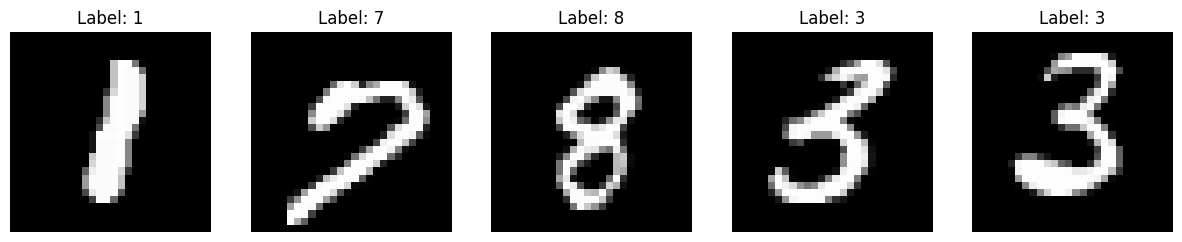

In [6]:
import matplotlib.pyplot as plt

# Display 5 random images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
indices = np.random.choice(len(train_images), 5, replace=False)

for idx, ax in enumerate(axes):
    # Reshape back to 28x28 for plotting
    ax.imshow(train_images[indices[idx]].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {np.argmax(train_labels[indices[idx]])}")
    ax.axis('off')
plt.show()

In [7]:
class MNIST_CNN(Module):
    def __init__(self):
        super().__init__()
        # 28x28x1 Input -> Conv Layer (8 filters)
        self.conv1 = Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.relu1 = ReLU()
        self.pool1 = MaxPool2d(kernel_size=2, stride=2)
        
        # Flatten: 8 channels * 14 * 14
        self.flatten = Flatten()
        
        # Fully Connected Layer: 1568 inputs -> 10 output classes
        self.fc1 = Linear(in_features=(8 * 14 * 14), out_features=10)

    def forward(self, x):
        # Pass data through the layers
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return F.Softmax(x)

In [8]:
model = MNIST_CNN()
model.train()
criterion = CrossEntropyLoss()
optimizer = SGD(layers=[model.conv1, model.fc1], lr=0.01)

num_samples = len(train_images)
epochs = 5

for epoch in range(epochs):
    epoch_loss = 0
    correct = 0
    
    for i in range(num_samples):
        # 1. Forward Pass
        prediction = model(train_images[i])
        
        # 2. Loss Calculation
        loss = criterion.forward(prediction, train_labels[i])
        epoch_loss += loss
        
        # Check accuracy
        if np.argmax(prediction) == np.argmax(train_labels[i]):
            correct += 1
            
        # 3. Backward Pass
        d_out = criterion.backward()
        d_out = model.fc1.backward(d_out)
        d_out = model.flatten.backward(d_out)
        d_out = model.pool1.backward(d_out)
        d_out = model.relu1.backward(d_out)
        d_out = model.conv1.backward(d_out)
        
        # 4. Update Weights
        optimizer.step()
        optimizer.zero_grad()

    print(f"Epoch {epoch+1} | Loss: {epoch_loss/num_samples:.4f} | Accuracy: {(correct/num_samples)*100:.2f}%")

print("Training Complete!")

Epoch 1 | Loss: 0.8573 | Accuracy: 72.00%
Epoch 2 | Loss: 0.4129 | Accuracy: 87.52%
Epoch 3 | Loss: 0.3395 | Accuracy: 90.16%
Epoch 4 | Loss: 0.2780 | Accuracy: 91.92%
Epoch 5 | Loss: 0.2252 | Accuracy: 93.44%
Training Complete!



--- Running Evaluation on Test Set ---

Final Test Accuracy: 90.00%

--- High-Confidence Errors ---


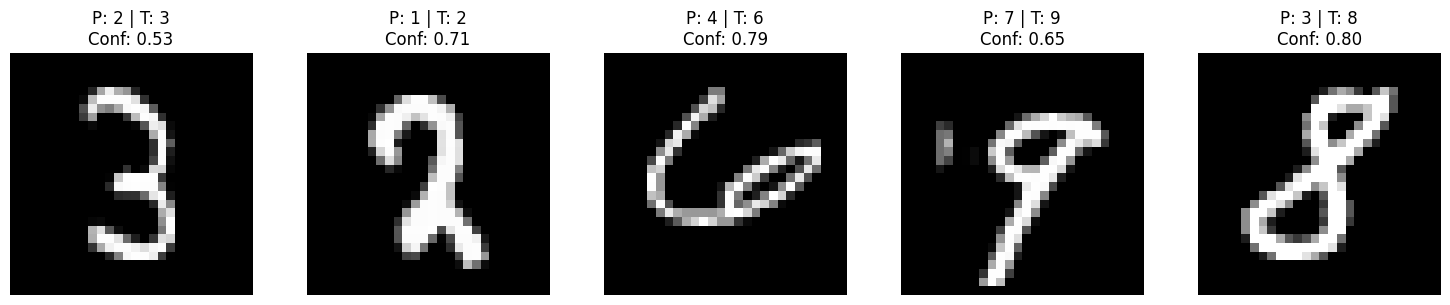


--- High-Confidence Corrects ---


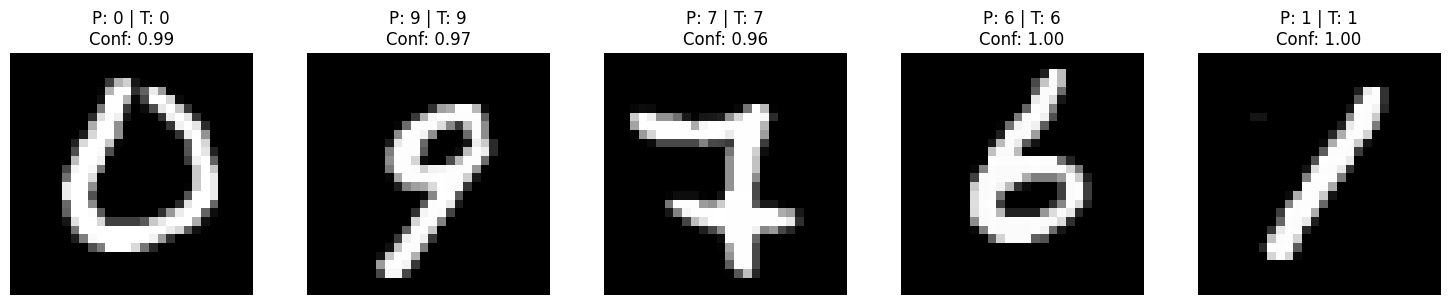

In [9]:
model.eval()
wrong_predictions = []
correct_predictions = []
total_correct = 0  

print("\n--- Running Evaluation on Test Set ---")
for i in range(len(test_images)):
    prediction = model(test_images[i])
    
    pred_idx = np.argmax(prediction)
    true_idx = np.argmax(test_labels[i])
    confidence = np.max(prediction)
    
    if pred_idx == true_idx:
        total_correct += 1
    
    if pred_idx != true_idx and confidence > 0.5:
        wrong_predictions.append((i, pred_idx, true_idx, confidence))
    elif pred_idx == true_idx and confidence > 0.9:
        correct_predictions.append((i, pred_idx, true_idx, confidence))

accuracy = total_correct / len(test_images)
print(f"\nFinal Test Accuracy: {accuracy:.2%}")

def show_results(data_list, title):
    if len(data_list) == 0:
        print(f"No {title} found.")
        return
        
    print(f"\n--- {title} ---")
    plt.figure(figsize=(15, 3))
    for i, (idx, pred, actual, conf) in enumerate(data_list[:5]):
        plt.subplot(1, 5, i + 1)
        plt.imshow(test_images[idx].reshape(28, 28), cmap='gray')
        plt.title(f"P: {pred} | T: {actual}\nConf: {conf:.2f}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_results(wrong_predictions, "High-Confidence Errors")
show_results(correct_predictions, "High-Confidence Corrects")